In [2]:
# === AIS Data Preprocessing: load, inspect, compare, visualise ===
# Imports (run this cell first)
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import wkb
from parse_AIS import list_vessels, extract_trajectory, plot_trajectory_on_map

base_dir = Path(r"C:\Users\marcs\OneDrive\Documents\BACHELOR THESIS")

# Load one day of AIS GeoParquet and show structure
parquet_path = base_dir / "ais-2024-01-01.parquet"
print("Reading:", parquet_path)

ais_df = pd.read_parquet(parquet_path)

print("Shape (rows, columns):", ais_df.shape)
print("Columns:", list(ais_df.columns))

ais_df.head()

Reading: C:\Users\marcs\OneDrive\Documents\BACHELOR THESIS\ais-2024-01-01.parquet
Shape (rows, columns): (7293408, 16)
Columns: ['mmsi', 'base_date_time', 'sog', 'cog', 'heading', 'vessel_name', 'imo', 'call_sign', 'vessel_type', 'status', 'length', 'width', 'draft', 'cargo', 'transceiver', 'geometry']


,mmsi,base_date_time,sog,cog,heading,vessel_name,imo,call_sign,vessel_type,status,length,width,draft,cargo,transceiver,geometry
0,338075892,2024-01-01 00:00:03,0.0,358.799988,<NA>,PILOT BOAT SPRING PT,,WDB8945,90,0,<NA>,<NA>,<NA>,90,A,b'\x01\x01\x00\x00\x00\xb1\xa2\x06\xd30\x90Q\x...
1,367669550,2024-01-01 00:00:04,0.0,281.899994,141,ALASKA CHALLENGER,IMO7938024,WDH9586,30,<NA>,30.0,8,<NA>,30,A,b'\x01\x01\x00\x00\x00\x82\xc5\xe1\xcc\xaf\xd8...
2,367118980,2024-01-01 00:00:06,0.0,30.1,296,CAPT J A MORGAN,IMO1186680,WDD2725,31,12,115.0,34,3.0,57,A,b'\x01\x01\x00\x00\x00g~5\x07\x08\x9aV\xc0\xce...
3,367177840,2024-01-01 00:00:05,0.0,304.399994,<NA>,BART TURECAMO,IMO7338808,WBR4464,52,<NA>,33.0,5,<NA>,52,A,b'\x01\x01\x00\x00\x00\x8c\x84\xb6\x9cK\xcbR\x...
4,367305420,2024-01-01 00:00:06,0.0,332.600006,<NA>,DOROTHY MORAN,IMO7716995,WXU4654,52,0,33.0,11,<NA>,52,A,b'\x01\x01\x00\x00\x00\xb4\x93\xc1Q\xf2<P\xc0\...


In [3]:
# Column types, dtypes, and non-null counts
ais_df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 7293408 entries, 0 to 7293407
Data columns (total 16 columns):
 #   Column          Dtype                
---  ------          -----                
 0   mmsi            int32[pyarrow]       
 1   base_date_time  timestamp[s][pyarrow]
 2   sog             float[pyarrow]       
 3   cog             float[pyarrow]       
 4   heading         int32[pyarrow]       
 5   vessel_name     string               
 6   imo             string               
 7   call_sign       string               
 8   vessel_type     int32[pyarrow]       
 9   status          int32[pyarrow]       
 10  length          float[pyarrow]       
 11  width           int32[pyarrow]       
 12  draft           float[pyarrow]       
 13  cargo           int32[pyarrow]       
 14  transceiver     string               
 15  geometry        object               
dtypes: float[pyarrow](4), int32[pyarrow](6), object(1), string(4), timestamp[s][pyarrow](1)
memory usage: 1.1 GB


In [4]:
# Summary stats for SOG, COG, length, width, draft
numeric_cols = ["sog", "cog", "length", "width", "draft"]

ais_df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
sog,7276775.0,1.779897,3.976771,0.0,0.0,0.0,0.3,97.199997
cog,6083090.0,190.265684,105.035052,0.0,101.699997,207.600006,275.799988,359.899994
length,7152775.0,64.079894,80.283666,1.0,17.0,26.0,73.0,489.0
width,7077032.0,12.990367,10.562221,1.0,6.0,9.0,16.0,61.0
draft,4234610.0,4.467328,2.885564,0.1,2.8,3.1,5.5,23.200001


In [5]:
# Counts by vessel type and status code

print("Vessel types (top 10):")
print(ais_df["vessel_type"].value_counts().head(10))

print("\nStatus codes (top 10):")
print(ais_df["status"].value_counts().head(10))

Vessel types (top 10):
vessel_type
31    1441365
37    1387385
52    1209413
30     545293
36     465413
70     459050
60     451111
80     210382
57     126553
90     124389
Name: count, dtype: int64[pyarrow]

Status codes (top 10):
status
0     2741789
12     857360
5      772941
1      204200
3      104640
11      46671
8       44776
7       39344
9       11495
2       10126
Name: count, dtype: int64[pyarrow]


In [6]:
# Unique MMSI, vessel names, IMO

n_mmsi = ais_df["mmsi"].nunique()
n_vessel_names = ais_df["vessel_name"].nunique()
n_imo = ais_df["imo"].dropna().nunique()

print("Number of distinct MMSI (ships):", n_mmsi)
print("Number of distinct vessel names:", n_vessel_names)
print("Number of distinct IMO numbers (non-null):", n_imo)

print("\nExample vessel names (first 20):")
for name in sorted(ais_df["vessel_name"].dropna().unique())[:20]:
    print("-", name)

Number of distinct MMSI (ships): 14857
Number of distinct vessel names: 13036
Number of distinct IMO numbers (non-null): 4705

Example vessel names (first 20):
- 
- #R DREAM
- & YACHT SCARLET
- '80S LADY
- 0.C.D
- 007
- 007 (DOUBLE-O-SEVEN)
- 1+1
- 11:11
- 123 GO
- 1492
- 17
- 2 AUSTINTATIOUS
- 2 SEA
- 2 SEA SONS
- 21 SEA SANDS
- 21 WHALER
- 268 BOOSTER
- 27 REASONS
- 29206


In [7]:
# --- Trajectory extraction (professor's helper) ---
# List vessels and extract one trajectory from CSV
csv_file = base_dir / "AIS_2024_01_01.csv"

# List vessels present in this day (from CSV)
vessels = list_vessels(csv_file)
print("Number of unique vessels in CSV:", len(vessels))
print("First 20 vessel names:")
for name in vessels[:20]:
    print("-", name)

# Choose one vessel for a detailed trajectory example
example_vessel = vessels[0]
print("\nUsing vessel for trajectory example:", example_vessel)

traj = extract_trajectory(csv_file, example_vessel)
traj.head()

Number of unique vessels in CSV: 13041
First 20 vessel names:
- #R DREAM
- & YACHT SCARLET
- '80S LADY
- 0.C.D
- 007
- 007 (DOUBLE-O-SEVEN)
- 1+1
- 11:11
- 123 GO
- 1492
- 17
- 2 AUSTINTATIOUS
- 2 SEA
- 2 SEA SONS
- 21 SEA SANDS
- 21 WHALER
- 268 BOOSTER
- 27 REASONS
- 29206
- 2ND LT JOHN P BOBO

Using vessel for trajectory example: #R DREAM


,BaseDateTime,LAT,LON,SOG,COG
0,2024-01-01 00:00:09,24.57741,-81.78844,0.1,360.0
1,2024-01-01 00:03:05,24.57741,-81.78844,0.1,360.0
2,2024-01-01 00:06:08,24.57740,-81.78843,0.0,360.0
3,2024-01-01 00:09:07,24.57741,-81.78842,0.1,360.0
4,2024-01-01 00:12:09,24.57740,-81.78843,0.1,360.0


In [8]:
# Save trajectory map to HTML (open in browser to view)
plot_trajectory_on_map(traj, map_file="trajectory_map.html")

Map saved to trajectory_map.html


Number of ship files: 22027
Selected MMSIs: [103669999, 109070092, 123456789]


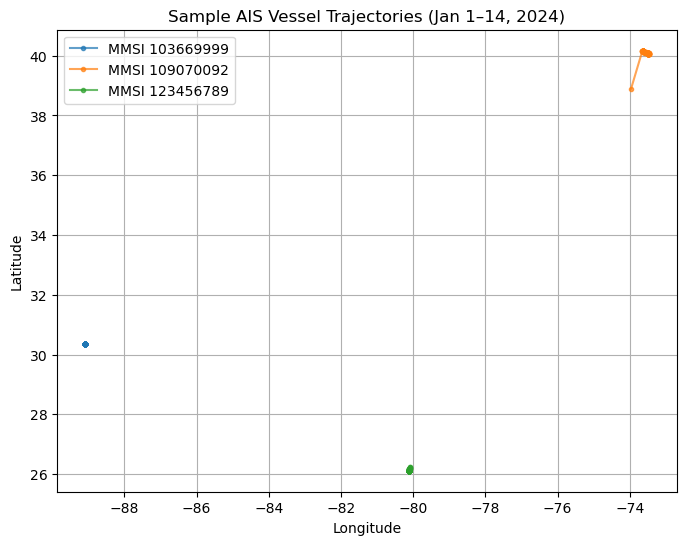

In [9]:
# --- Per-ship parquets: trajectory visualisation ---
# Plot trajectories for 3 random ships (Jan 1–14)
by_ship_dir = base_dir / "data" / "processed" / "by_ship"
ship_files = list(by_ship_dir.glob("MMSI_*.parquet"))
print("Number of ship files:", len(ship_files))

# Pick a few ships that have enough points
samples = []
for f in ship_files:
    df = pd.read_parquet(f)
    if len(df) >= 100:  # skip ships with very few points
        mmsi = int(df["mmsi"].iloc[0])
        samples.append((mmsi, df))
    if len(samples) == 3:
        break

print("Selected MMSIs:", [m for m, _ in samples])

plt.figure(figsize=(8, 6))
for mmsi, df in samples:
    plt.plot(df["LON"], df["LAT"], marker=".", linestyle="-", alpha=0.7, label=f"MMSI {mmsi}")

plt.title("Sample AIS Vessel Trajectories (Jan 1–14, 2024)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()

Zooming on MMSI: 103669999 with 2644 points


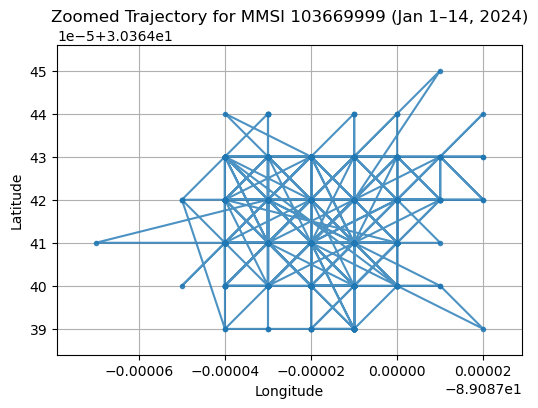

In [16]:
# Zoom into one ship's trajectory
zoom_mmsi = samples[0][0]
zoom_df = samples[0][1]

print("Zooming on MMSI:", zoom_mmsi, "with", len(zoom_df), "points")

min_lon, max_lon = zoom_df["LON"].min(), zoom_df["LON"].max()
min_lat, max_lat = zoom_df["LAT"].min(), zoom_df["LAT"].max()

# Add a small margin around the trajectory
lon_margin = (max_lon - min_lon) * 0.1 or 0.01
lat_margin = (max_lat - min_lat) * 0.1 or 0.01

plt.figure(figsize=(6, 6))
plt.plot(zoom_df["LON"], zoom_df["LAT"], marker=".", linestyle="-", alpha=0.8)
plt.title(f"Zoomed Trajectory for MMSI {zoom_mmsi} (Jan 1–14, 2024)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(min_lon - lon_margin, max_lon + lon_margin)
plt.ylim(min_lat - lat_margin, max_lat + lat_margin)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True)
plt.show()

In [11]:
# --- Sanity check: Parquet vs CSV ---
# Compare LAT/LON for same IMO ships in both formats
parquet_path = base_dir / "ais-2024-01-01.parquet"
csv_path     = base_dir / "AIS_2024_01_01.csv"

print("Reading parquet and CSV for 2024-01-01...")
parq_df = pd.read_parquet(parquet_path)

# Add LAT/LON from geometry (same logic as in extract_routes_by_ship.py)
geom = parq_df["geometry"].apply(lambda x: wkb.loads(x) if isinstance(x, bytes) else x)
gdf  = gpd.GeoDataFrame(parq_df, geometry=geom)
parq_df = parq_df.copy()
parq_df["LAT"] = gdf.geometry.y
parq_df["LON"] = gdf.geometry.x

csv_df = pd.read_csv(csv_path)

# Normalise IMO strings
parq_df["imo"] = parq_df["imo"].fillna("").astype(str).str.strip()
csv_df["IMO"] = csv_df["IMO"].fillna("").astype(str).str.strip()

common_imos = sorted(set(parq_df["imo"]) & set(csv_df["IMO"]))
common_imos = [imo for imo in common_imos if imo][:5]

print("\nCommon IMOs (up to 5):", common_imos)

for imo in common_imos:
    print("\n=== IMO:", imo, "===")
    print("Parquet (first 5 points):")
    print(
        parq_df[parq_df["imo"] == imo][["base_date_time", "LAT", "LON"]]
        .head(5)
        .to_string(index=False)
    )
    print("\nCSV (first 5 points):")
    print(
        csv_df[csv_df["IMO"] == imo][["BaseDateTime", "LAT", "LON"]]
        .head(5)
        .to_string(index=False)
    )


Reading parquet and CSV for 2024-01-01...

Common IMOs (up to 5): ['IMO0000001', 'IMO0000002', 'IMO0000003', 'IMO0000004', 'IMO0000005']

=== IMO: IMO0000001 ===
Parquet (first 5 points):
     base_date_time      LAT       LON
2024-01-01 00:00:05 29.63875 -91.25217
2024-01-01 00:00:05 30.07408 -92.65192
2024-01-01 00:00:01 29.90089 -89.99132
2024-01-01 00:00:03 30.20855 -90.49180
2024-01-01 00:00:04 30.01792 -93.98056

CSV (first 5 points):
       BaseDateTime      LAT       LON
2024-01-01T00:00:05 29.63875 -91.25217
2024-01-01T00:00:05 30.07408 -92.65192
2024-01-01T00:00:01 29.90089 -89.99132
2024-01-01T00:00:03 30.20855 -90.49180
2024-01-01T00:00:04 30.01792 -93.98056

=== IMO: IMO0000002 ===
Parquet (first 5 points):
     base_date_time      LAT       LON
2024-01-01 00:00:14 29.77396 -95.10141
2024-01-01 00:01:24 29.77397 -95.10142
2024-01-01 00:02:25 29.77397 -95.10142
2024-01-01 00:03:35 29.77396 -95.10142
2024-01-01 00:04:56 29.77397 -95.10142

CSV (first 5 points):
       BaseDa

In [12]:
# --- Single-ship analysis: time-gap histogram ---
# Pick ship with most points; plot trajectory + gaps (helps choose sampling, e.g. 1/min)
by_ship_dir = base_dir / "data" / "processed" / "by_ship"
ship_files = list(by_ship_dir.glob("MMSI_*.parquet"))

best = None
for f in ship_files:
    df = pd.read_parquet(f)
    if len(df) >= 500 and (best is None or len(df) > len(best[2])):
        best = (int(df["mmsi"].iloc[0]), f, df)
if best is None:
    raise SystemExit("No ship with >= 500 points found.")
mmsi, path, ship = best
ship = ship.sort_values("base_date_time").reset_index(drop=True)

# Time gaps (seconds) between consecutive AIS reports
ts = pd.to_datetime(ship["base_date_time"])
dt_sec = ts.diff().dt.total_seconds().dropna()

print(f"Ship MMSI {mmsi}: {len(ship)} points")
print(f"Time span: {ts.iloc[0]} to {ts.iloc[-1]}")
print(f"Time gaps (seconds): median={dt_sec.median():.0f}, mean={dt_sec.mean():.1f}, std={dt_sec.std():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: trajectory colored by time (start=blue, end=red)
ax = axes[0]
sc = ax.scatter(ship["LON"], ship["LAT"], c=np.arange(len(ship)), cmap="viridis", s=1, alpha=0.7)
ax.set_title(f"Full trajectory MMSI {mmsi} (color = point order)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
ax.grid(True)

# Right: histogram of time gaps (helps choose e.g. 1 per 60 seconds)
ax = axes[1]
ax.hist(dt_sec.clip(upper=300), bins=50, edgecolor="black", alpha=0.7)  # clip long gaps for visibility
ax.axvline(60, color="red", linestyle="--", label="60 s (1/min)")
ax.set_title("Seconds between consecutive AIS reports")
ax.set_xlabel("Seconds")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

# Example: keep 1 point per minute (first in each minute)
# ship_min = ship.groupby(ts.dt.floor("min")).first().reset_index(drop=True)
# print("Downsampled to 1/min:", len(ship_min), "points")

TypeError: object of type 'WindowsPath' has no len()